In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
base_path = Path(".") # change to path folder with data 


# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

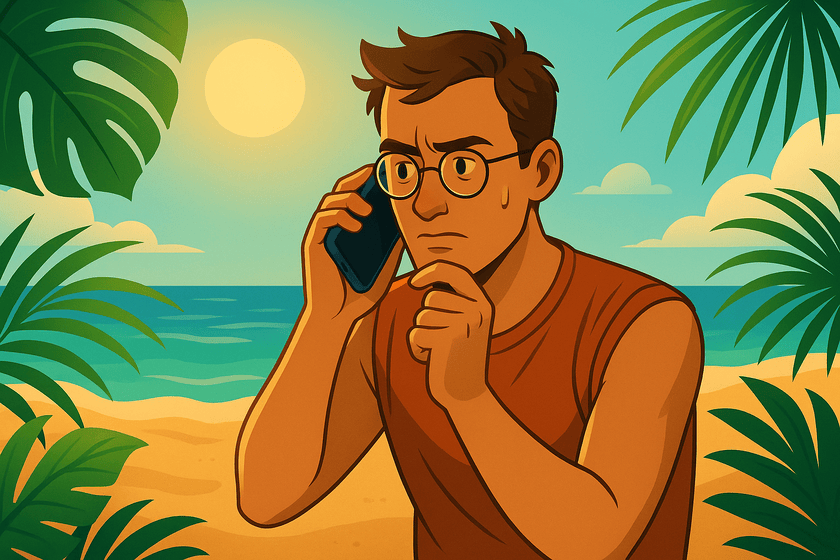

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


In [4]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

In [5]:
titanic_df.Survived.value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [6]:
titanic_df['Cabin'].str[0].unique()

<StringArray>
[nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T']
Length: 9, dtype: str

## 1. Pierwsze zapoznanie z danymi

In [7]:
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    str    
 8   Fare      793 non-null    float64
 9   Cabin     204 non-null    str    
 10  Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 76.7 KB


In [8]:
titanic_df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,793.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,33.123938
std,0.486592,0.836071,14.526497,1.102743,0.806057,51.578312
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.925000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.500000
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.275000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
titanic_df.describe(include='str')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


braki w `Age` (177), `Fare` (98), `Cabin` (687), `Embarked` (2); `Fare` ma podejrzany max (512 vs śr. ~33) — możliwy outlier; `Ticket`/`Cabin` mają powtórzenia

## 2. Braki danych

### 2.1 Embarked

In [11]:
titanic_df[titanic_df['Embarked'].isnull()]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [12]:
titanic_df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [13]:
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0])

### 2.2 Age

In [14]:
titanic_df.groupby(['Pclass', 'Sex'])['Age'].median()

Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

In [15]:
titanic_df['Age'] = titanic_df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

In [16]:
titanic_df['Age'].isnull().sum()

np.int64(0)

### 2.3 Fare

In [17]:
titanic_df.groupby('Pclass')['Fare'].median()

Pclass
1    60.2875
2    14.0000
3     8.0500
Name: Fare, dtype: float64

In [18]:
titanic_df['Fare'] = titanic_df.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))

In [19]:
titanic_df['Fare'].isnull().sum()

np.int64(0)

### 2.4 Cabin

In [20]:
titanic_df['Deck'] = titanic_df['Cabin'].str[0]
titanic_df['Deck'] = titanic_df['Deck'].fillna('Unknown')
titanic_df['Deck'].value_counts()

Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

In [21]:
titanic_df = titanic_df.drop(columns=['Cabin'])

In [22]:
titanic_df.isnull().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
Deck        0
dtype: int64

In [23]:
titanic_df['Title'] = titanic_df['Name'].str.extract(r',\s*([^.]+)\.', expand=False)
print(titanic_df['Title'].value_counts())

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


In [24]:
titanic_df['Title'] = titanic_df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
rare_titles = ['Dr', 'Rev', 'Col', 'Major', 'Lady', 'Sir', 'Capt', 'Don', 'Jonkheer', 'the Countess']
titanic_df['Title'] = titanic_df['Title'].replace(rare_titles, 'Rare')
print(titanic_df['Title'].value_counts())

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


In [25]:
titanic_df['FamilySize'] = titanic_df['SibSp'] + titanic_df['Parch'] + 1
titanic_df['IsAlone'] = (titanic_df['FamilySize'] == 1).astype(int)
titanic_df[['Name', 'SibSp', 'Parch', 'FamilySize', 'IsAlone']].head(8)

,Name,SibSp,Parch,FamilySize,IsAlone
PassengerId,,,,,
1,"Braund, Mr. Owen Harris",1,0,2,0
2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0,2,0
3,"Heikkinen, Miss. Laina",0,0,1,1
4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0,2,0
5,"Allen, Mr. William Henry",0,0,1,1
6,"Moran, Mr. James",0,0,1,1
7,"McCarthy, Mr. Timothy J",0,0,1,1
8,"Palsson, Master. Gosta Leonard",3,1,5,0


In [26]:
titanic_df['Fare_log'] = np.log1p(titanic_df['Fare'])
titanic_df[['Fare', 'Fare_log']].describe()

,Fare,Fare_log
count,891.000000,891.000000
mean,31.756069,2.951859
std,49.325538,0.958760
min,0.000000,0.000000
25%,8.050000,2.202765
50%,14.000000,2.708050
75%,31.275000,3.474293
max,512.329200,6.240917


## 4. Wartości skrajne (Outliers)

In [27]:
def detect_outliers_iqr(series, k=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR
    mask = (series < lower) | (series > upper)
    return lower, upper, series[mask]

print("=== Age ===")
low, up, outs = detect_outliers_iqr(titanic_df['Age'])
print(f"Granice 1.5*IQR: [{low:.1f}, {up:.1f}]  |  outlierów: {len(outs)}")
print(outs.sort_values().tail(10))

print("\n=== Fare ===")
low, up, outs = detect_outliers_iqr(titanic_df['Fare'])
print(f"Granice 1.5*IQR: [{low:.1f}, {up:.1f}]  |  outlierów: {len(outs)}")
print(outs.describe())

=== Age ===
Granice 1.5*IQR: [-0.2, 57.8]  |  outlierów: 33
PassengerId
281    65.0
457    65.0
34     66.0
746    70.0
673    70.0
117    70.5
97     71.0
494    71.0
852    74.0
631    80.0
Name: Age, dtype: float64

=== Fare ===
Granice 1.5*IQR: [-26.8, 66.1]  |  outlierów: 105
count    105.000000
mean     131.650792
std       87.899330
min       66.600000
25%       77.958300
50%       91.079200
75%      151.550000
max      512.329200
Name: Fare, dtype: float64


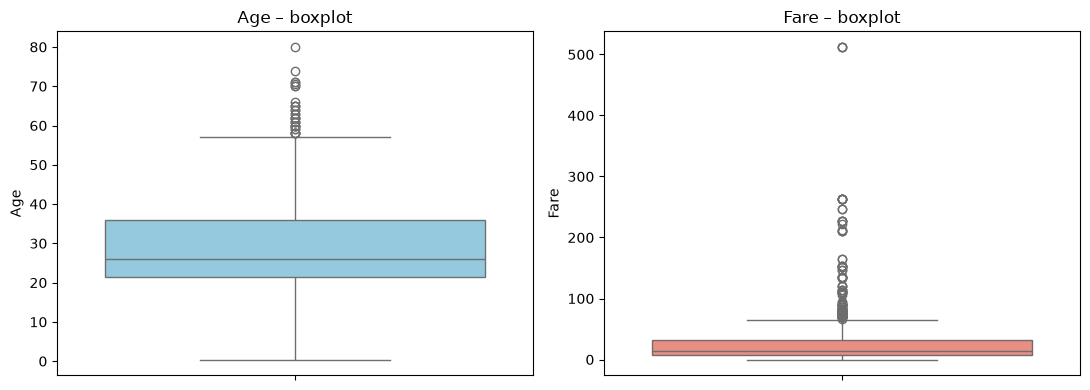

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(y=titanic_df['Age'], ax=axes[0], color='skyblue')
axes[0].set_title('Age – boxplot')
sns.boxplot(y=titanic_df['Fare'], ax=axes[1], color='salmon')
axes[1].set_title('Fare – boxplot')
plt.tight_layout()
plt.show()

In [29]:
print("Deck:\n", titanic_df['Deck'].value_counts())
print("\nTitle:\n", titanic_df['Title'].value_counts())
print("\nFamilySize:\n", titanic_df['FamilySize'].value_counts().sort_index())

Deck:
 Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

Title:
 Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

FamilySize:
 FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64


**Wnioski:** Outliery Age i Fare zostawiamy – są realne. Deck=T i duże FamilySize też zostają.

## 5. Wizualizacje
### 5.1 Zmienna docelowa i cechy kategorialne

C:\Users\Alex\AppData\Local\Temp\ipykernel_17528\1237488027.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Zginął (0)', 'Przeżył (1)'])


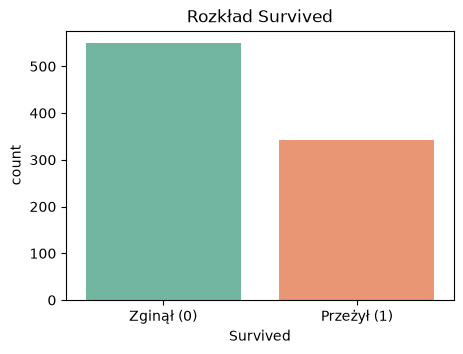

Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


In [30]:
fig, ax = plt.subplots(figsize=(5, 3.5))
sns.countplot(x='Survived', data=titanic_df, hue='Survived', palette='Set2', ax=ax, legend=False)
ax.set_title('Rozkład Survived')
ax.set_xticklabels(['Zginął (0)', 'Przeżył (1)'])
plt.show()
print(titanic_df['Survived'].value_counts(normalize=True).round(3))

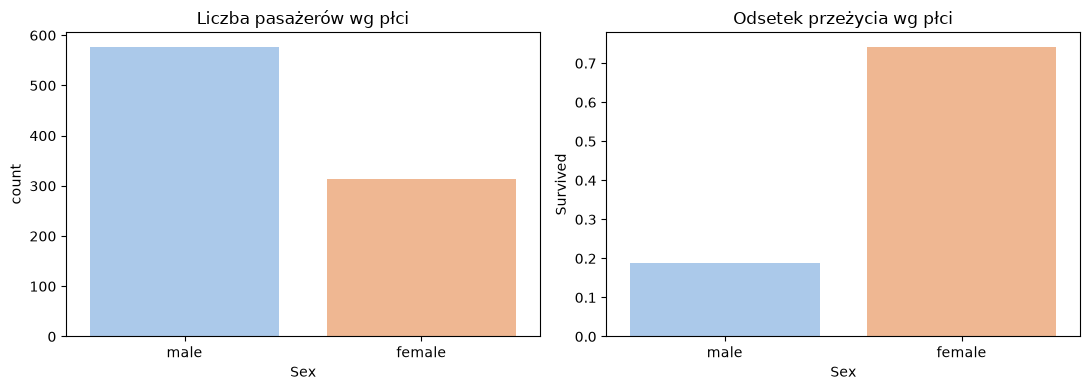

Sex
female    0.742
male      0.189
Name: Survived, dtype: float64


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x='Sex', data=titanic_df, hue='Sex', palette='pastel', ax=axes[0], legend=False)
axes[0].set_title('Liczba pasażerów wg płci')
sns.barplot(x='Sex', y='Survived', data=titanic_df, hue='Sex', palette='pastel', ax=axes[1], errorbar=None, legend=False)
axes[1].set_title('Odsetek przeżycia wg płci')
plt.tight_layout()
plt.show()
print(titanic_df.groupby('Sex')['Survived'].mean().round(3))

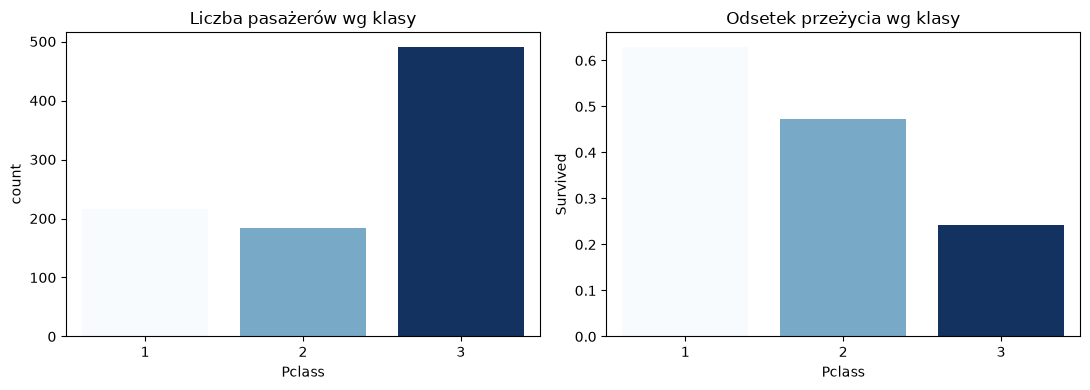

Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x='Pclass', data=titanic_df, hue='Pclass', palette='Blues', ax=axes[0], legend=False)
axes[0].set_title('Liczba pasażerów wg klasy')
sns.barplot(x='Pclass', y='Survived', data=titanic_df, hue='Pclass', palette='Blues', ax=axes[1], errorbar=None, legend=False)
axes[1].set_title('Odsetek przeżycia wg klasy')
plt.tight_layout()
plt.show()
print(titanic_df.groupby('Pclass')['Survived'].mean().round(3))

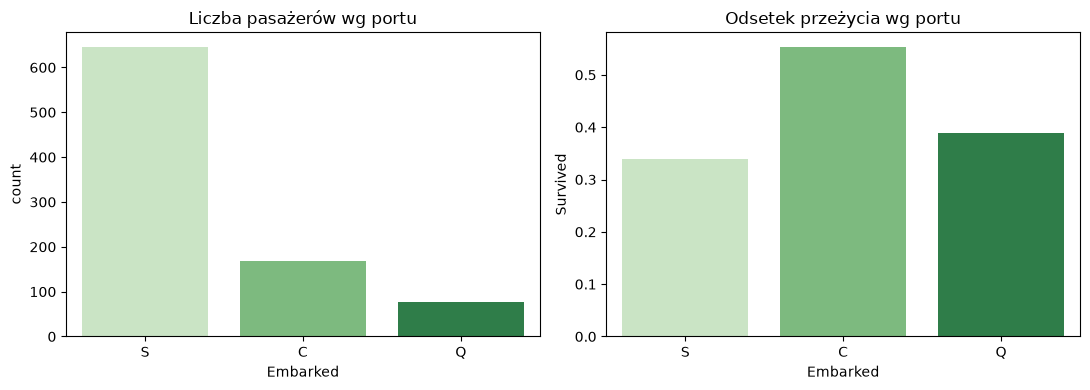

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
order = ['S', 'C', 'Q']
sns.countplot(x='Embarked', data=titanic_df, order=order, hue='Embarked', palette='Greens', ax=axes[0], legend=False)
axes[0].set_title('Liczba pasażerów wg portu')
sns.barplot(x='Embarked', y='Survived', data=titanic_df, order=order, hue='Embarked', palette='Greens', ax=axes[1], errorbar=None, legend=False)
axes[1].set_title('Odsetek przeżycia wg portu')
plt.tight_layout()
plt.show()

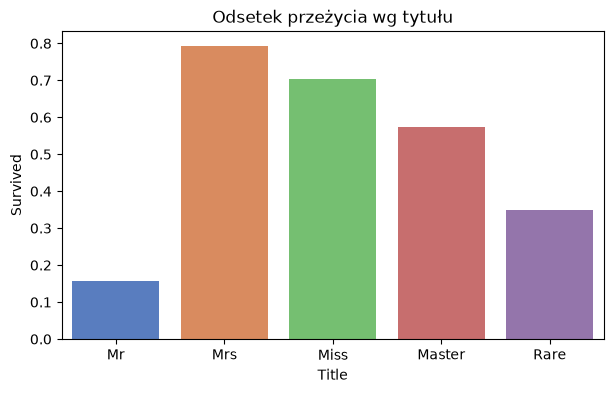

         mean  count
Title               
Master  0.575     40
Miss    0.703    185
Mr      0.157    517
Mrs     0.794    126
Rare    0.348     23


In [34]:
plt.figure(figsize=(7, 4))
order_t = ['Mr', 'Mrs', 'Miss', 'Master', 'Rare']
sns.barplot(x='Title', y='Survived', data=titanic_df, order=order_t, hue='Title', palette='muted', errorbar=None, legend=False)
plt.title('Odsetek przeżycia wg tytułu')
plt.show()
print(titanic_df.groupby('Title')['Survived'].agg(['mean', 'count']).round(3))

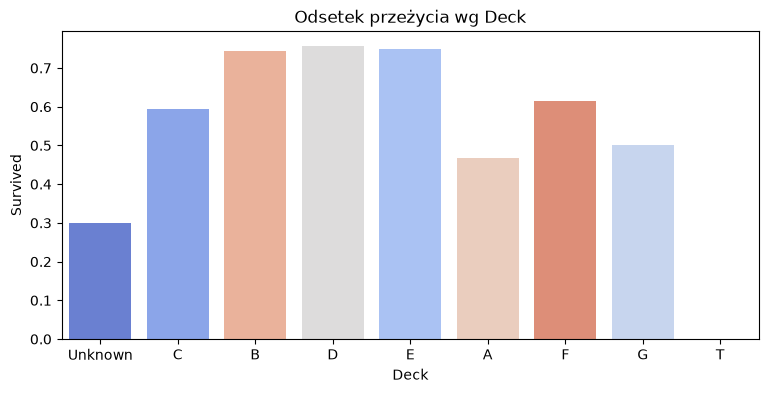

In [35]:
plt.figure(figsize=(9, 4))
order_d = titanic_df['Deck'].value_counts().index
sns.barplot(x='Deck', y='Survived', data=titanic_df, order=order_d, hue='Deck', palette='coolwarm', errorbar=None, legend=False)
plt.title('Odsetek przeżycia wg Deck')
plt.show()

C:\Users\Alex\AppData\Local\Temp\ipykernel_17528\1940119781.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Z rodziną (0)', 'Sam (1)'])


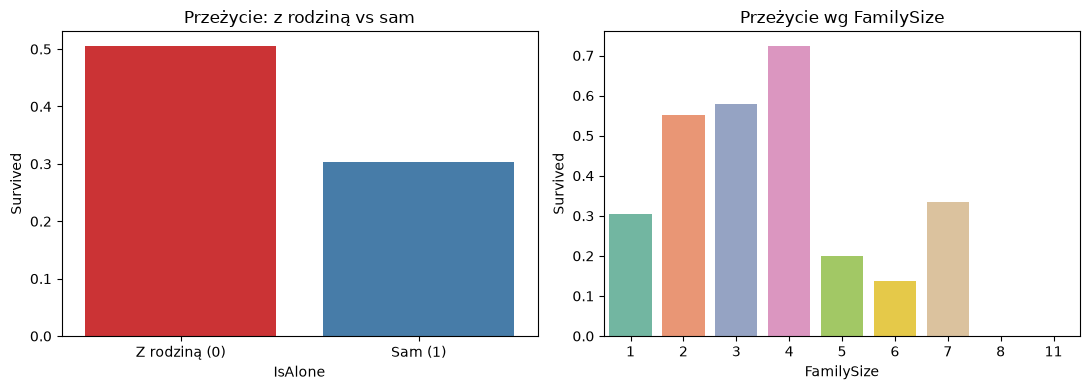

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(x='IsAlone', y='Survived', data=titanic_df, hue='IsAlone', palette='Set1', ax=axes[0], errorbar=None, legend=False)
axes[0].set_title('Przeżycie: z rodziną vs sam')
axes[0].set_xticklabels(['Z rodziną (0)', 'Sam (1)'])
sns.barplot(x='FamilySize', y='Survived', data=titanic_df, hue='FamilySize', palette='Set2', ax=axes[1], errorbar=None, legend=False)
axes[1].set_title('Przeżycie wg FamilySize')
plt.tight_layout()
plt.show()

### 5.2 Cechy numeryczne

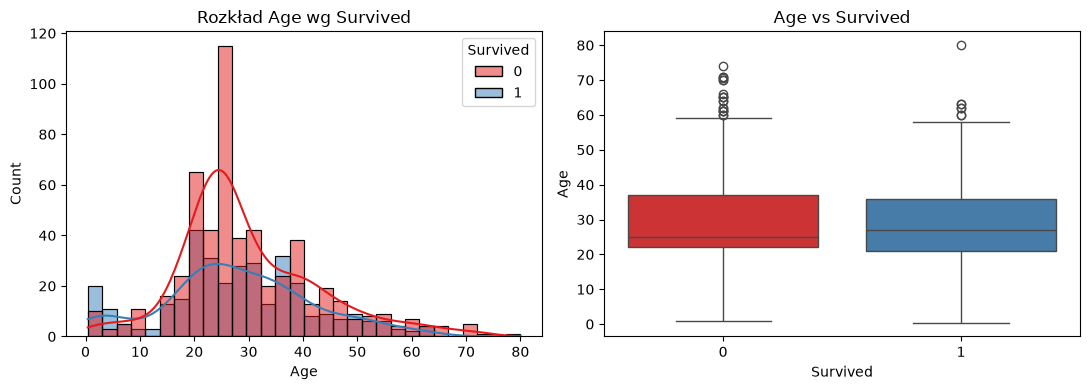

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(data=titanic_df, x='Age', hue='Survived', kde=True, ax=axes[0], palette='Set1', bins=30)
axes[0].set_title('Rozkład Age wg Survived')
sns.boxplot(x='Survived', y='Age', data=titanic_df, hue='Survived', palette='Set1', ax=axes[1], legend=False)
axes[1].set_title('Age vs Survived')
plt.tight_layout()
plt.show()

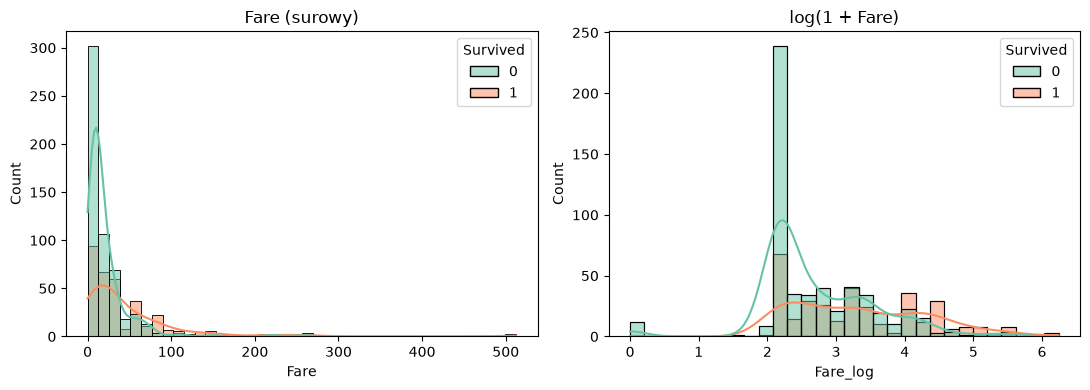

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(data=titanic_df, x='Fare', hue='Survived', kde=True, ax=axes[0], palette='Set2', bins=40)
axes[0].set_title('Fare (surowy)')
sns.histplot(data=titanic_df, x='Fare_log', hue='Survived', kde=True, ax=axes[1], palette='Set2', bins=30)
axes[1].set_title('log(1 + Fare)')
plt.tight_layout()
plt.show()

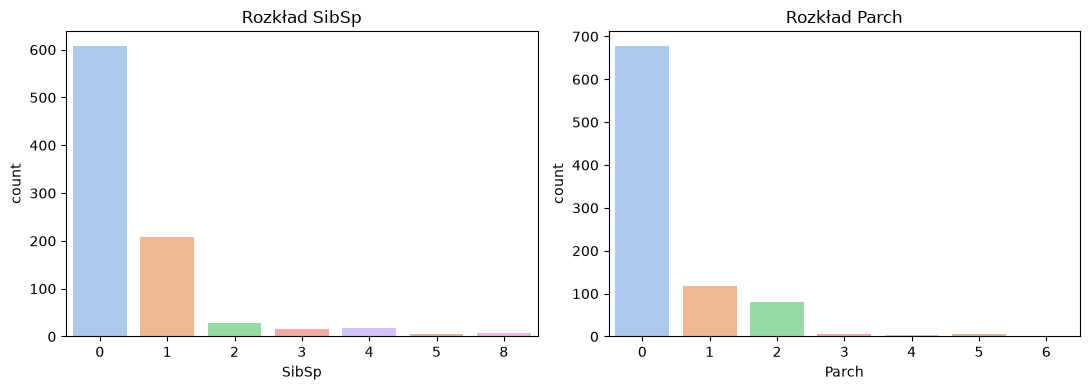

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x='SibSp', data=titanic_df, hue='SibSp', palette='pastel', ax=axes[0], legend=False)
axes[0].set_title('Rozkład SibSp')
sns.countplot(x='Parch', data=titanic_df, hue='Parch', palette='pastel', ax=axes[1], legend=False)
axes[1].set_title('Rozkład Parch')
plt.tight_layout()
plt.show()

### 5.3 Zależności parami i korelacja

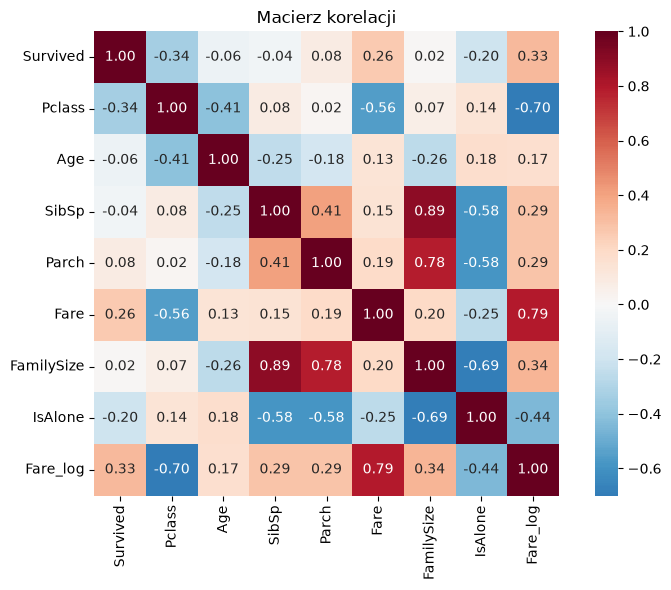

In [40]:
num_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'Fare_log']
corr = titanic_df[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Macierz korelacji')
plt.tight_layout()
plt.show()

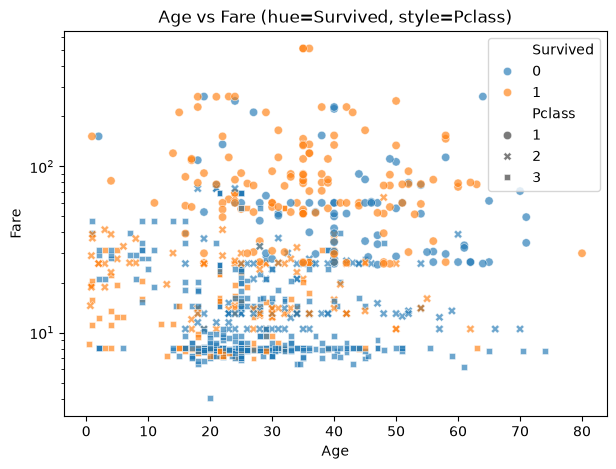

In [41]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=titanic_df, x='Age', y='Fare', hue='Survived', style='Pclass', alpha=0.65)
plt.title('Age vs Fare (hue=Survived, style=Pclass)')
plt.yscale('log')
plt.show()

## 6. Kodowanie cech kategorialnych

In [42]:
df = titanic_df.copy()

df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['Embarked', 'Title', 'Deck'], drop_first=True, dtype=int)
df = df.drop(columns=['Name', 'Ticket'])

print("Kształt:", df.shape)
print("Kolumny:", df.columns.tolist())
df.head()

Kształt: (891, 24)
Kolumny: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'Fare_log', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_Unknown']


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Fare_log,...,Title_Mrs,Title_Rare,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown
PassengerId,,,,,,,,,,,,,,,,,,,,,
1,0,3,0,22.0,1,0,7.2500,2,0,2.110213,...,0,0,0,0,0,0,0,0,0,1
2,1,1,1,38.0,1,0,71.2833,2,0,4.280593,...,1,0,0,1,0,0,0,0,0,0
3,1,3,1,26.0,0,0,7.9250,1,1,2.188856,...,0,0,0,0,0,0,0,0,0,1
4,1,1,1,35.0,1,0,53.1000,2,0,3.990834,...,1,0,0,1,0,0,0,0,0,0
5,0,3,0,35.0,0,0,8.0500,1,1,2.202765,...,0,0,0,0,0,0,0,0,0,1


In [43]:
print("Suma braków:", df.isnull().sum().sum())
df.info()

Suma braków: 0
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Survived      891 non-null    int64  
 1   Pclass        891 non-null    int64  
 2   Sex           891 non-null    int64  
 3   Age           891 non-null    float64
 4   SibSp         891 non-null    int64  
 5   Parch         891 non-null    int64  
 6   Fare          891 non-null    float64
 7   FamilySize    891 non-null    int64  
 8   IsAlone       891 non-null    int64  
 9   Fare_log      891 non-null    float64
 10  Embarked_Q    891 non-null    int64  
 11  Embarked_S    891 non-null    int64  
 12  Title_Miss    891 non-null    int64  
 13  Title_Mr      891 non-null    int64  
 14  Title_Mrs     891 non-null    int64  
 15  Title_Rare    891 non-null    int64  
 16  Deck_B        891 non-null    int64  
 17  Deck_C        891 non-null    int64  
 18  Deck_D        891 non-null

## 7. Podsumowanie

In [44]:
print("=== Finalny zbiór ===")
print(f"Wiersze: {df.shape[0]}, kolumny: {df.shape[1]}")
print(f"Survived rate: {df['Survived'].mean():.3f}")
df.describe().T

=== Finalny zbiór ===
Wiersze: 891, kolumny: 24
Survived rate: 0.384


,count,mean,std,min,25%,50%,75%,max
Survived,891.0,0.383838,0.486592,0.00,0.000000,0.00000,1.000000,1.000000
Pclass,891.0,2.308642,0.836071,1.00,2.000000,3.00000,3.000000,3.000000
Sex,891.0,0.352413,0.477990,0.00,0.000000,0.00000,1.000000,1.000000
Age,891.0,29.112424,13.304424,0.42,21.500000,26.00000,36.000000,80.000000
SibSp,891.0,0.523008,1.102743,0.00,0.000000,0.00000,1.000000,8.000000
Parch,891.0,0.381594,0.806057,0.00,0.000000,0.00000,0.000000,6.000000
Fare,891.0,31.756069,49.325538,0.00,8.050000,14.00000,31.275000,512.329200
FamilySize,891.0,1.904602,1.613459,1.00,1.000000,1.00000,2.000000,11.000000
IsAlone,891.0,0.602694,0.489615,0.00,0.000000,1.00000,1.000000,1.000000
Fare_log,891.0,2.951859,0.958760,0.00,2.202765,2.70805,3.474293,6.240917
